In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
print(df.shape)

(10000, 14)


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# check for missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
# checking for duplicated rows

df.duplicated().sum()

np.int64(0)

In [7]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
# Remove first 3 rows as it is not useful

df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# Apply OHE on categorical columns

df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [13]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [14]:
# now we have only numerical columns
# so now we can easily build our model 

In [15]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [17]:
print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [18]:
# first we have to do scaling on our training data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [20]:
# Now, we are ready to apply 'Keras' for making our simple ANN project

In [21]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-01-08 03:26:02.953175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767842763.292915      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767842763.392404      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767842764.235224      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767842764.235293      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767842764.235297      17 computation_placer.cc:177] computation placer alr

In [22]:
# in keras, we can create 2 types of layers (sequential and non-sequential)
# we are going to make here sequential model

In [23]:
model = Sequential()

# when this model is created then we add layers(1 i/p, 1 hidden and 1 output layer) on it.
# for starting, in hidden layer we put 3 nodes(perceptrons) there.

# this is our hidden layer
model.add(Dense(10, activation='relu', input_dim=11))  # as we have 11 i/p columns

# we add one more layer to improve our model
model.add(Dense(10, activation='relu'))

# this is our output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-08 03:26:21.963828: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
model.summary()     # it gives the summary of our model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
# now, we have to compile our model

model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [26]:
# fit the model

history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)    # it means we have to move 10 times on our data to find out weight and biases

# so we can store all our data in this dictionary(history)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6428 - loss: 0.6328 - val_accuracy: 0.8075 - val_loss: 0.4705
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8080 - loss: 0.4635 - val_accuracy: 0.8144 - val_loss: 0.4359
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8172 - loss: 0.4379 - val_accuracy: 0.8181 - val_loss: 0.4184
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8297 - loss: 0.4080 - val_accuracy: 0.8269 - val_loss: 0.4036
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8326 - loss: 0.4131 - val_accuracy: 0.8375 - val_loss: 0.3878
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8456 - loss: 0.3762 - val_accuracy: 0.8431 - val_loss: 0.3736
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8527 - loss: 0.3690 - val_accuracy: 0.8481 - val_loss: 0.3653
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8529 - loss: 0.3593 - val_accu

In [27]:
model.layers[0].get_weights()

# so these are 33 weights and 3 biases of the 1st layer. i.e., (11*3 weights + 3 biases)

[array([[-0.07144789, -0.0732573 ,  0.40487805, -0.52680874, -0.05859188,
         -0.0982419 , -0.02585691,  0.14356047,  0.18329734,  0.417319  ],
        [ 0.7960782 ,  0.7797946 ,  0.18840012, -0.40651235,  0.285956  ,
          0.798239  , -0.5446182 ,  0.5125258 , -0.36745408,  0.02323089],
        [ 0.25227267,  0.16367169,  0.3013024 ,  0.5222723 ,  0.0386335 ,
         -0.0596279 , -0.36350045,  0.16518113,  0.037896  , -0.14298657],
        [-0.05730696, -0.03471852, -0.86388755, -0.46594104, -0.02659731,
         -0.71282816,  0.11481636,  0.01671807, -0.45932102, -0.16095898],
        [ 0.4065863 , -0.7364383 , -0.07846148, -0.13717937,  1.1020871 ,
         -0.8630567 , -0.47573864,  0.361192  ,  0.3397166 ,  0.12492824],
        [ 0.27549186,  0.10242198,  0.21490113, -0.2241182 ,  0.07933772,
         -0.07751714,  0.0917529 ,  0.2720991 ,  0.18205285, -0.15353014],
        [ 0.8824942 , -0.05369842,  0.5564224 , -0.20626362,  0.23926872,
          0.07782024,  0.2523142

In [28]:
# similarly for 2nd layer 

model.layers[1].get_weights()   

# these are 3 weights and 1 bias 

[array([[ 0.11764299, -0.3643916 , -0.3141239 , -0.7840388 , -0.40403542,
          0.31899667, -0.56917363,  1.0082558 , -0.13492528,  0.07977163],
        [-0.21820967,  0.11161523,  0.36754683,  0.1556116 ,  0.57786584,
          0.32159522, -0.09352713, -0.22744085, -0.6964703 , -0.16808094],
        [-0.42708346,  0.50104135,  0.67192453,  0.52165437,  0.03196783,
          0.5046972 ,  0.01433455,  0.42042094, -0.7412888 ,  0.09170274],
        [-0.3065954 ,  0.09172378,  0.40350193,  0.5906043 , -0.9164034 ,
          0.11851334,  0.50360584,  0.43671712,  0.36103112, -0.10078765],
        [ 1.0127707 ,  0.36936978, -0.4078587 , -0.479889  , -0.18332015,
          0.34965017, -0.31102106, -0.50376266,  0.630041  ,  0.94889534],
        [-0.3336652 ,  0.24225241,  0.13644102,  0.40323415, -0.21293482,
          0.09261344, -0.5911456 ,  0.05116225, -0.11498775, -2.3092055 ],
        [-0.49164477, -0.45635614,  0.26591727,  0.28230613,  0.06264478,
          0.35820004,  0.5778135

In [29]:
# now we can predict easily for this model

y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [30]:
# so we can see here that output is not in form of (0/1) 
# it is because we use here 'sigmoid_function' and it gives probability as an output.

In [31]:
# let's assume, threshold=0.5 and then we have say below it (o/p=0) and above it is (o/p=1)

y_pred = np.where(y_log>0.5, 1,0)   # if yes->1, o/w 0

In [32]:
# check for its accuracy

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.864

In [33]:
# now, we can imporve our accuracy through changing in NN(neural n/w)

# like we can increase no. of epochs, increase no. of nodes of hidden layer
# it seemes that if we use activation='relu' then it will give better result

# so we can see our resultis improved after making these type of changes

In [34]:
# now, it's time to plot the graph

import matplotlib.pyplot as plt

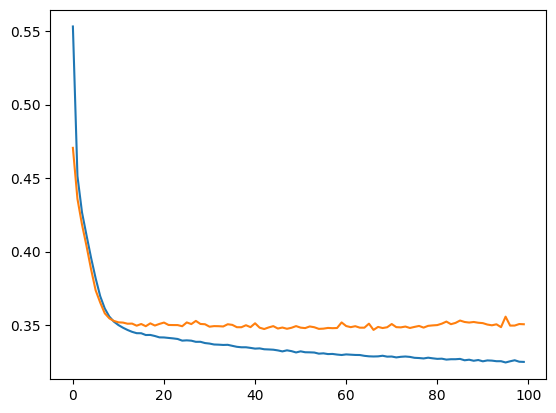

In [35]:
# so this represents that how our 'training_error' reduced b/w epochs = (1 to 100)
plt.plot(history.history['loss'])


# compare it with 'validation_loss'
plt.plot(history.history['val_loss'])

# so this gap b/w both represent that there is some level of overfitting happens.

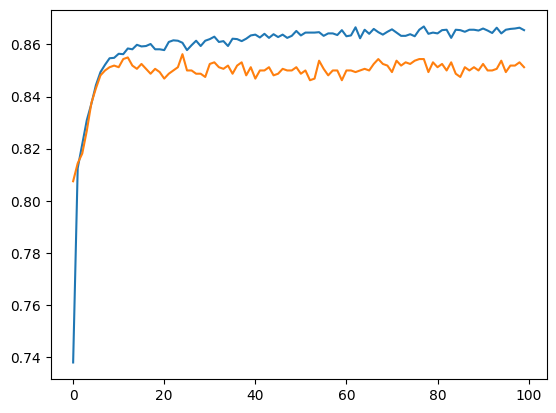

In [36]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])


# this also represents there is some level of overfitting happens

In [37]:
# So, this is how we make our simple Neural Network using 'Keras'.